# Optuna Neuro Network

### Imports

In [1]:
import pandas as pd
import numpy as np
import time
import optuna
import optuna.visualization as vis

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import math

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-25 01:57:57.549884: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-25 01:57:57.549938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-25 01:57:57.551553: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 01:57:57.561065: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to 

### Load and Shuffle Data

In [2]:
df = pd.read_csv("housing_cleaned.csv")
df = shuffle(df, random_state=42)

### Split Dataset

In [3]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Scale Dataset

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Compare to Baseline Model

In [5]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

In [6]:
start = time.time()

In [7]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [8]:
end = time.time()
print(f"Training time: {(end - start)/60:.2f} minutes")

Training time: 0.92 minutes


In [9]:
y_pred = model.predict(X_test_scaled).flatten()

rmse = mean_squared_error(y_test, y_pred, squared=False)
print("Baseline NN RMSE (log scale):", rmse)

135/135 [==============================] - 0s 654us/step
Baseline NN RMSE (log scale): 0.2045124061605759


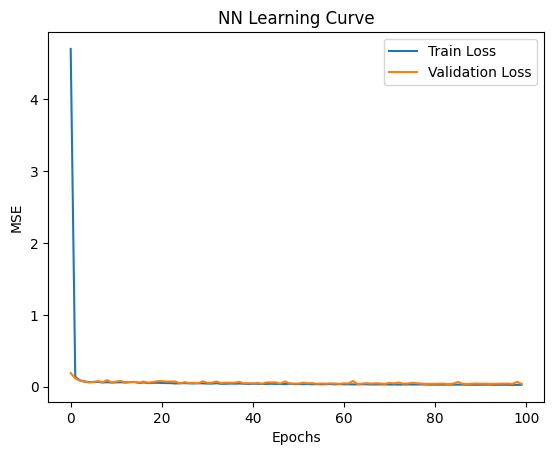

In [10]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('NN Learning Curve')
plt.legend()
plt.show()

Baseline Model is Underfitting

## Tuning with Optuna: Neuro Network \+ Cross Validation

In [11]:
def objective(trial):

    # Locked / narrowed params
    n_layers = 2
    learning_rate = trial.suggest_float("learning_rate", 0.001, 0.003, log=True)
    batch_size = 16
    epochs = trial.suggest_int("epochs", 100, 200)

    l2_reg = trial.suggest_float("l2", 1e-5, 1e-4, log=True)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.25)

    # Model
    model = Sequential()

    model.add(Dense(
        trial.suggest_int("units_l0", 90, 180),
        activation='relu',
        kernel_regularizer=l2(l2_reg),
        input_shape=(X_train_scaled.shape[1],)
    ))
    model.add(Dropout(dropout_rate))

    model.add(Dense(
        trial.suggest_int("units_l1", 50, 150),
        activation='relu',
        kernel_regularizer=l2(l2_reg)
    ))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )

    return min(history.history['val_loss'])

In [12]:
start = time.time()

In [13]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, n_jobs = 1)

[I 2026-04-25 01:58:58,160] A new study created in memory with name: no-name-45923449-a585-4710-b256-4eb646cab523
[I 2026-04-25 01:59:47,262] Trial 0 finished with value: 0.03386734798550606 and parameters: {'learning_rate': 0.0027018474908378125, 'epochs': 106, 'l2': 1.4715281238396472e-05, 'dropout': 0.16419776135445285, 'units_l0': 112, 'units_l1': 63}. Best is trial 0 with value: 0.03386734798550606.
[I 2026-04-25 02:01:22,103] Trial 1 finished with value: 0.032462067902088165 and parameters: {'learning_rate': 0.0011906698731585107, 'epochs': 147, 'l2': 1.4615212798108898e-05, 'dropout': 0.11883299249405484, 'units_l0': 99, 'units_l1': 146}. Best is trial 1 with value: 0.032462067902088165.
[I 2026-04-25 02:02:21,658] Trial 2 finished with value: 0.032193366438150406 and parameters: {'learning_rate': 0.001915772820561658, 'epochs': 105, 'l2': 2.690275538148578e-05, 'dropout': 0.10023340598203691, 'units_l0': 178, 'units_l1': 119}. Best is trial 2 with value: 0.032193366438150406.
[

In [14]:
end = time.time()
print(f"Total time: {(end - start)/60:.2f} minutes")

Total time: 28.38 minutes


### Examine Best Hyperparameter Values from Tuning

In [15]:
print("Best Params:")
print(study.best_params)

print("Best Loss:")
print(study.best_value)

Best Params:
{'learning_rate': 0.001273969712117897, 'epochs': 188, 'l2': 1.0174404942123178e-05, 'dropout': 0.15890951085333707, 'units_l0': 137, 'units_l1': 88}
Best Loss:
0.03016848862171173


### Optuna Specific Visualizations

In [16]:
vis.plot_optimization_history(study)

In [17]:
vis.plot_param_importances(study)

In [18]:
vis.plot_slice(
    study,
    params=[
        'learning_rate',
        'epochs',
        'dropout',
        'l2',
        'units_l0',
        'units_l1'
    ]
)

### Extract Best Hyperparameter Values from Tuning

In [19]:
best_params = study.best_params

### Create Model Using Best Parameters

In [20]:
model = Sequential()

model.add(Dense(best_params['units_l0'], activation='relu',
                kernel_regularizer=l2(best_params['l2']),
                input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(best_params['dropout']))

model.add(Dense(best_params['units_l1'], activation='relu',
                kernel_regularizer=l2(best_params['l2'])))
model.add(Dropout(best_params['dropout']))

model.add(Dense(1))

In [21]:
model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='mse'
)

In [22]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=best_params['epochs'],
    batch_size=16,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

### Results

In [23]:
y_pred = model.predict(X_test_scaled).flatten()

rmse_log = mean_squared_error(y_test, y_pred, squared=False)
print("Final Test RMSE:", rmse_log)

135/135 [==============================] - 0s 510us/step
Final Test RMSE: 0.17576850202122338


In [24]:
# Convert Log RMSE to something easier to interpert.
print(math.exp(rmse_log))

1.1921620435999714


### Visualize the Results

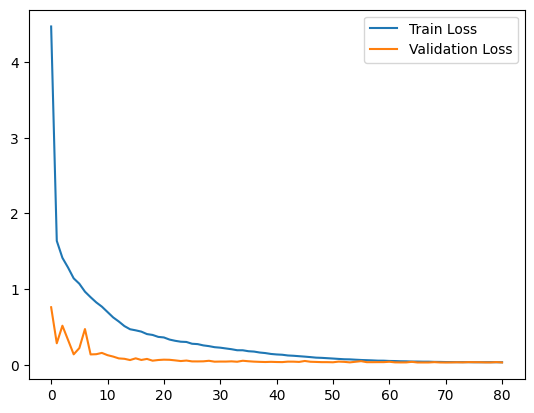

In [25]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

### Mean Absolute Precentage Error \(MAPE\)

MAPE = "On average, predictions are off by X% of the true value"

In [26]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# Convert back to original price scale
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
print("MAPE (actual prices):", mape)

MAPE (actual prices): 0.12689979951445332


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=89799500-4443-401d-b5a6-3a6742d3b89e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>